<a href="https://colab.research.google.com/github/omarpb03/Data-Science-ML-Fundamentals-Python/blob/main/PCA_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import load_breast_cancer

In [2]:
breast = load_breast_cancer()

In [3]:
breast_data = breast.data

In [4]:
breast_data.shape

(569, 30)

In [5]:
breast_labels = breast.target

In [6]:
breast_labels.shape

(569,)

In [7]:
import numpy as np

In [8]:
labels = np.reshape(breast_labels,(569,1))

In [9]:
final_breast_data = np.concatenate([breast_data, labels], axis = 1)

In [10]:
import pandas as pd

In [11]:
breast_dataset = pd.DataFrame(final_breast_data)

In [12]:
features = breast.feature_names

In [13]:
features

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

In [14]:
features_labels = np.append(features, 'label')

In [15]:
features_labels

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension', 'label'], dtype='<U23')

In [16]:
breast_dataset.columns = features_labels

In [17]:
breast_dataset.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0.0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0.0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0.0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0.0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0.0


In [18]:
breast_dataset['label'].replace(0, 'Benign', inplace = True)
breast_dataset['label'].replace(1, 'Malignant', inplace = True)

/tmp/ipykernel_1499/4258123049.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  breast_dataset['label'].replace(0, 'Benign', inplace = True)


In [19]:
breast_dataset.tail()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,Benign
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,Benign
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,Benign
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,Benign
568,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,Malignant


In [20]:
from keras.datasets import cifar10

In [21]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 457s 3us/step


In [22]:
x_train.shape

(50000, 32, 32, 3)

In [23]:
y_train.shape

(50000, 1)

In [24]:
x_test.shape

(10000, 32, 32, 3)

array([[[154, 177, 187],
        [126, 137, 136],
        [105, 104,  95],
        ...,
        [ 91,  95,  71],
        [ 87,  90,  71],
        [ 79,  81,  70]],

       [[140, 160, 169],
        [145, 153, 154],
        [125, 125, 118],
        ...,
        [ 96,  99,  78],
        [ 77,  80,  62],
        [ 71,  73,  61]],

       [[140, 155, 164],
        [139, 146, 149],
        [115, 115, 112],
        ...,
        [ 79,  82,  64],
        [ 68,  70,  55],
        [ 67,  69,  55]],

       ...,

       [[175, 167, 166],
        [156, 154, 160],
        [154, 160, 170],
        ...,
        [ 42,  34,  36],
        [ 61,  53,  57],
        [ 93,  83,  91]],

       [[165, 154, 128],
        [156, 152, 130],
        [159, 161, 142],
        ...,
        [103,  93,  96],
        [123, 114, 120],
        [131, 121, 131]],

       [[163, 148, 120],
        [158, 148, 122],
        [163, 156, 133],
        ...,
        [143, 133, 139],
        [143, 134, 142],
        [143, 133, 144]]], dtype=uint8)
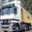

In [25]:
x_train[1]

array([[[255, 255, 255],
        [253, 253, 253],
        [253, 253, 253],
        ...,
        [253, 253, 253],
        [253, 253, 253],
        [253, 253, 253]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [254, 254, 254],
        [254, 254, 254],
        ...,
        [254, 254, 254],
        [254, 254, 254],
        [254, 254, 254]],

       ...,

       [[113, 120, 112],
        [111, 118, 111],
        [105, 112, 106],
        ...,
        [ 72,  81,  80],
        [ 72,  80,  79],
        [ 72,  80,  79]],

       [[111, 118, 110],
        [104, 111, 104],
        [ 99, 106,  98],
        ...,
        [ 68,  75,  73],
        [ 70,  76,  75],
        [ 78,  84,  82]],

       [[106, 113, 105],
        [ 99, 106,  98],
        [ 95, 102,  94],
        ...,
        [ 78,  85,  83],
        [ 79,  85,  83],
        [ 80,  86,  84]]], dtype=uint8)
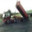

In [26]:
x_train[2]

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [248, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [247, 251, 250],
        [209, 237, 245],
        ...,
        [172, 207, 226],
        [234, 243, 246],
        [252, 253, 253]],

       [[252, 255, 255],
        [206, 236, 249],
        [105, 194, 228],
        ...,
        [ 55, 140, 193],
        [157, 198, 225],
        [236, 246, 250]],

       ...,

       [[255, 255, 255],
        [232, 232, 232],
        [185, 183, 183],
        ...,
        [ 44, 175, 226],
        [119, 198, 234],
        [217, 239, 250]],

       [[255, 255, 255],
        [243, 244, 244],
        [201, 205, 208],
        ...,
        [120, 184, 214],
        [204, 232, 245],
        [249, 253, 254]],

       [[255, 255, 255],
        [253, 255, 254],
        [242, 249, 252],
        ...,
        [221, 232, 237],
        [249, 250, 251],
        [254, 254, 254]]], dtype=uint8)
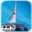

In [27]:
x_train[397]

array([[[134, 139, 143],
        [139, 144, 148],
        [144, 150, 153],
        ...,
        [120, 124, 123],
        [102, 102, 107],
        [ 64,  61,  70]],

       [[126, 131, 133],
        [142, 148, 153],
        [146, 152, 156],
        ...,
        [ 89,  90,  90],
        [ 42,  44,  54],
        [ 14,  16,  28]],

       [[ 96,  99,  97],
        [129, 131, 129],
        [135, 140, 141],
        ...,
        [ 27,  29,  34],
        [  8,  13,  23],
        [  8,  14,  25]],

       ...,

       [[121, 141, 174],
        [120, 141, 180],
        [126, 145, 185],
        ...,
        [ 26,  30,  43],
        [ 26,  30,  42],
        [ 23,  27,  38]],

       [[118, 138, 174],
        [122, 143, 182],
        [127, 147, 186],
        ...,
        [ 27,  30,  43],
        [ 23,  27,  37],
        [ 20,  24,  33]],

       [[115, 134, 171],
        [120, 141, 178],
        [126, 145, 183],
        ...,
        [ 22,  25,  36],
        [ 19,  23,  34],
        [ 19,  22,  32]]], dtype=uint8)
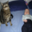

In [28]:
x_train[8988]

In [29]:
classes = np.unique(y_train)
nClasses = len(classes)
print('Total numero de clases:', nClasses)
print('Las clases son:', classes)

Total numero de clases: 10
Las clases son: [0 1 2 3 4 5 6 7 8 9]


In [32]:
label_dict = {
    0: 'avion',
    1: 'coche',
    2: 'pajaro',
    3: 'gato',
    4: 'buhos',
    5: 'perror',
    6: 'rana',
    7: 'caballo',
    8: 'barco',
    9: 'camion'
}

In [33]:
import matplotlib.pyplot as plt
%matplotlib inline

Text(0.5, 1.0, '(Label: rana)')
Text(0.5, 1.0, '(Label: gato)')


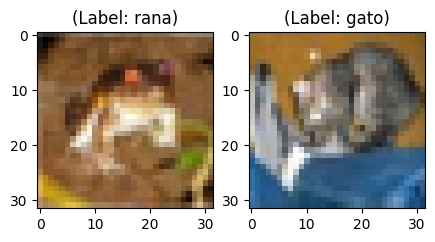

In [34]:
plt.figure(figsize = [5,5])

plt.subplot(121)
curr_img = np.reshape(x_train[0], (32,32,3))
plt.imshow(curr_img)
print(plt.title("(Label: "+ str(label_dict[y_train[0][0]]) + ")"))

plt.subplot(122)
curr_img = np.reshape(x_test[0], (32,32,3))
plt.imshow(curr_img)
print(plt.title("(Label: "+ str(label_dict[y_test[0][0]]) + ")"))


In [35]:
from sklearn.preprocessing import StandardScaler

In [36]:
x = breast_dataset.loc[:, features].values
x = StandardScaler().fit_transform(x)

In [37]:
feat_cols = ['feature' + str(i) for i in range(x.shape[1])]

In [38]:
normalised_breast = pd.DataFrame(x, columns = feat_cols)

In [39]:
normalised_breast.head()

,feature0,feature1,feature2,feature3,feature4,feature5,feature6,feature7,feature8,feature9,...,feature20,feature21,feature22,feature23,feature24,feature25,feature26,feature27,feature28,feature29
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


In [40]:
from sklearn.decomposition import PCA

In [41]:
pca_breast = PCA(n_components = 2)

In [42]:
principalComponents = pca_breast.fit_transform(x)

In [43]:
principalComponents

array([[ 9.19283683,  1.94858307],
       [ 2.3878018 , -3.76817174],
       [ 5.73389628, -1.0751738 ],
       ...,
       [ 1.25617928, -1.90229671],
       [10.37479406,  1.67201011],
       [-5.4752433 , -0.67063679]])

In [44]:
principal_breast_df = pd.DataFrame(data = principalComponents, columns = ['principal component 1', 'principal component 2'])

In [45]:
principal_breast_df

,principal component 1,principal component 2
0,9.192837,1.948583
1,2.387802,-3.768172
2,5.733896,-1.075174
3,7.122953,10.275589
4,3.935302,-1.948072
...,...,...
564,6.439315,-3.576817
565,3.793382,-3.584048
566,1.256179,-1.902297
567,10.374794,1.672010


In [46]:
pca_breast.explained_variance_ratio_

array([0.44272026, 0.18971182])

<Figure size 640x480 with 0 Axes>

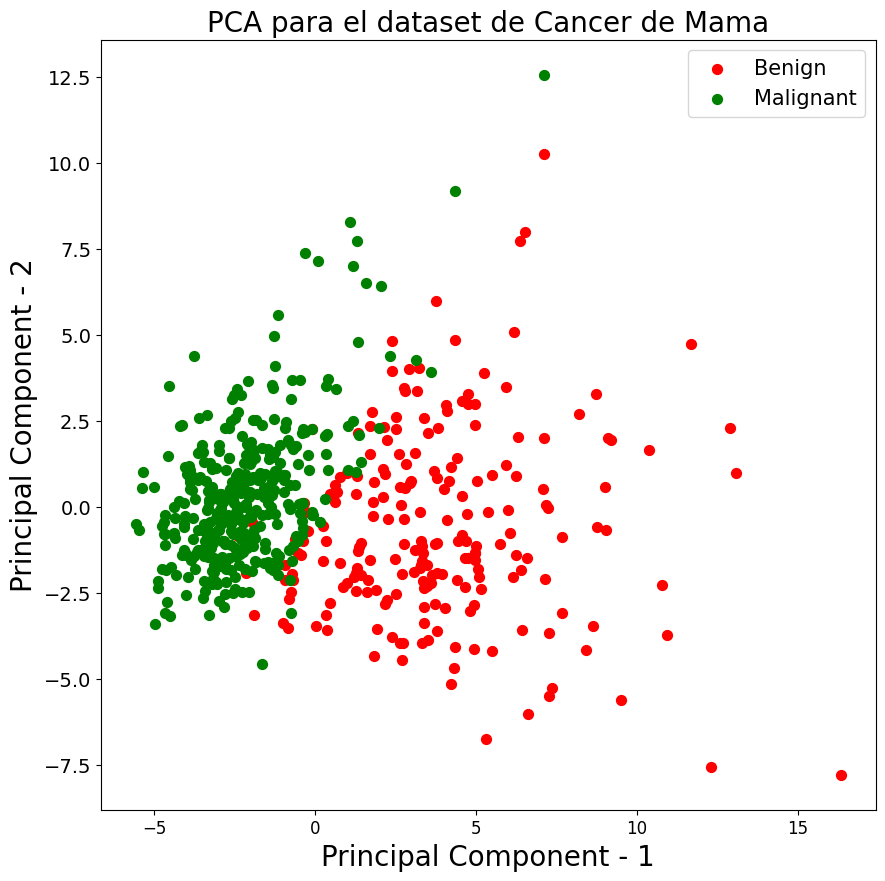

In [47]:
plt.figure()
plt.figure(figsize = (10,10))
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 14)
plt.xlabel('Principal Component - 1', fontsize = 20)
plt.ylabel('Principal Component - 2', fontsize = 20)
plt.title('PCA para el dataset de Cancer de Mama', fontsize = 20)
targets = ['Benign','Malignant']
colors = ['r','g']
for target, color in zip(targets, colors):
    indicesToKeep = breast_dataset['label'] == target
    plt.scatter(principal_breast_df.loc[indicesToKeep, 'principal component 1'],
                principal_breast_df.loc[indicesToKeep, 'principal component 2'], c = color, s = 50)

plt.legend(targets, prop = {'size':15})

In [48]:
np.min(x_train),np.max(x_train)

(np.uint8(0), np.uint8(255))

In [49]:
x_train.shape

(50000, 32, 32, 3)

In [50]:
x_train_flat = x_train.reshape(-1,3072)

In [51]:
x_train_flat

array([[ 59,  62,  63, ..., 123,  92,  72],
       [154, 177, 187, ..., 143, 133, 144],
       [255, 255, 255, ...,  80,  86,  84],
       ...,
       [ 35, 178, 235, ...,  12,  31,  50],
       [189, 211, 240, ..., 195, 190, 171],
       [229, 229, 239, ..., 163, 163, 161]], dtype=uint8)

In [52]:
feats_cols = ['pixel'+str(i) for i in range(x_train_flat.shape[1])]

In [53]:
df_cifar = pd.DataFrame(x_train_flat, columns = feats_cols)

In [54]:
df_cifar

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel3062,pixel3063,pixel3064,pixel3065,pixel3066,pixel3067,pixel3068,pixel3069,pixel3070,pixel3071
0,59,62,63,43,46,45,50,48,43,68,...,104,216,184,140,151,118,84,123,92,72
1,154,177,187,126,137,136,105,104,95,102,...,136,143,133,139,143,134,142,143,133,144
2,255,255,255,253,253,253,253,253,253,253,...,79,78,85,83,79,85,83,80,86,84
3,28,25,10,37,34,19,38,35,20,42,...,38,54,47,28,63,56,37,72,65,46
4,170,180,198,168,178,196,177,185,203,183,...,78,75,79,82,71,75,78,73,77,80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,145,161,194,151,166,199,156,171,205,155,...,57,39,41,56,36,38,53,37,39,54
49996,255,245,132,254,247,134,255,249,137,254,...,82,249,174,79,252,181,81,253,181,76
49997,35,178,235,40,176,239,42,176,241,39,...,87,27,52,77,21,43,66,12,31,50
49998,189,211,240,186,208,236,185,207,235,184,...,165,195,184,169,196,189,171,195,190,171


In [55]:
df_cifar['label'] = y_train

In [56]:
df_cifar

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel3063,pixel3064,pixel3065,pixel3066,pixel3067,pixel3068,pixel3069,pixel3070,pixel3071,label
0,59,62,63,43,46,45,50,48,43,68,...,216,184,140,151,118,84,123,92,72,6
1,154,177,187,126,137,136,105,104,95,102,...,143,133,139,143,134,142,143,133,144,9
2,255,255,255,253,253,253,253,253,253,253,...,78,85,83,79,85,83,80,86,84,9
3,28,25,10,37,34,19,38,35,20,42,...,54,47,28,63,56,37,72,65,46,4
4,170,180,198,168,178,196,177,185,203,183,...,75,79,82,71,75,78,73,77,80,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,145,161,194,151,166,199,156,171,205,155,...,39,41,56,36,38,53,37,39,54,2
49996,255,245,132,254,247,134,255,249,137,254,...,249,174,79,252,181,81,253,181,76,6
49997,35,178,235,40,176,239,42,176,241,39,...,27,52,77,21,43,66,12,31,50,9
49998,189,211,240,186,208,236,185,207,235,184,...,195,184,169,196,189,171,195,190,171,1


In [57]:
pca_cifar = PCA(n_components = 2)
principalComponents_cifar = pca_cifar.fit_transform(df_cifar.iloc[:,:-1])

In [58]:
principal_cifar_Df = pd.DataFrame(data = principalComponents_cifar, columns = ['principal componente 1','principal componente 2'])
principal_cifar_Df['y'] = y_train

In [59]:
principal_cifar_Df

,principal componente 1,principal componente 2,y
0,-1632.259496,695.904883,6
1,211.594763,-242.235516,9
2,1971.200943,-2938.136097,9
3,-2638.693419,2.738252,4
4,-669.541001,-1267.156174,1
...,...,...,...
49995,1812.039498,-1492.011111,2
49996,1585.305450,484.184882,6
49997,180.373380,-2892.342928,9
49998,2898.816799,-860.874267,1


In [60]:
pca_cifar.explained_variance_ratio_

array([0.2907663 , 0.11253144])

<Axes: xlabel='principal componente 1', ylabel='principal componente 2'>

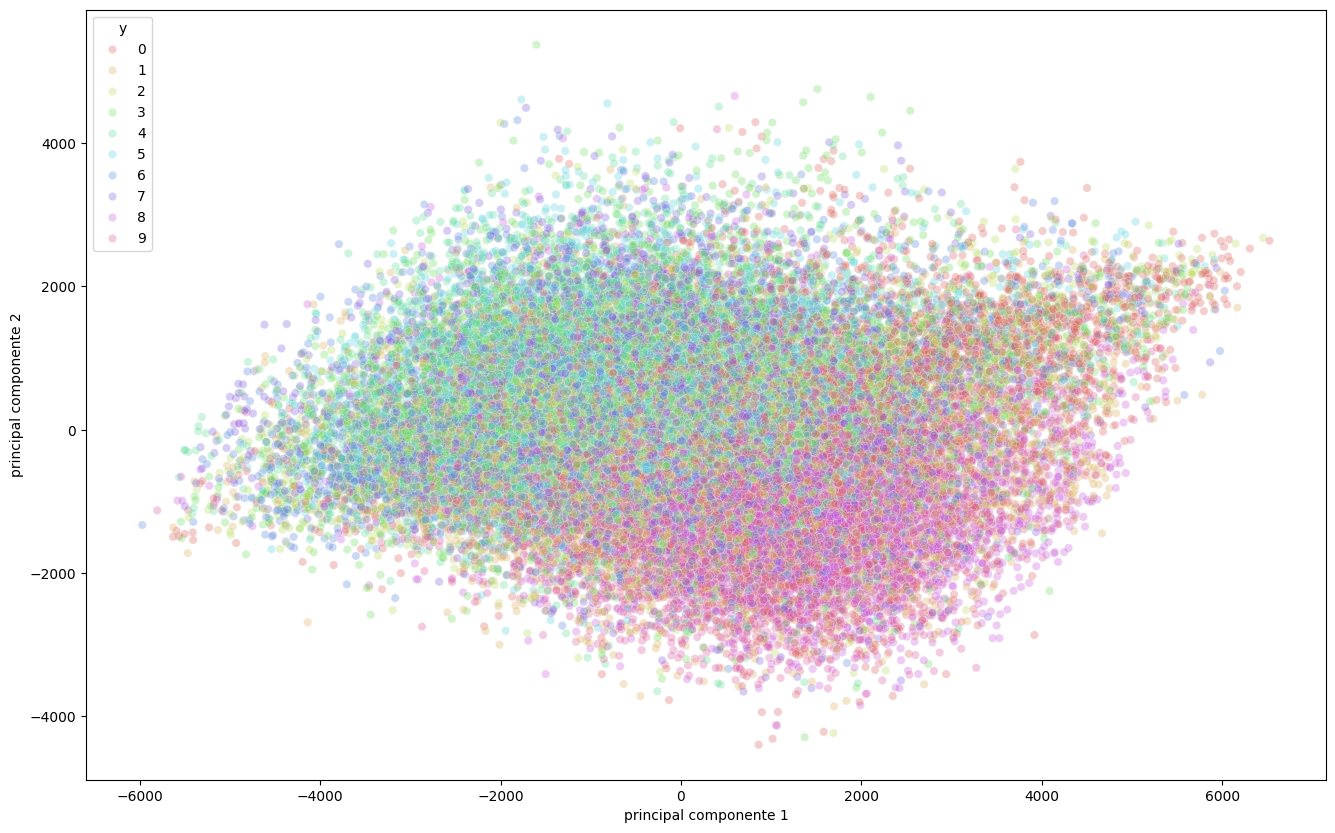

In [61]:
import seaborn as sns

plt.figure(figsize = (16,10))
sns.scatterplot(
    x = "principal componente 1", y = "principal componente 2",
    hue = "y",
    palette = sns.color_palette('hls',10),
    data = principal_cifar_Df,
    legend = 'full',
    alpha = 0.3
)